In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

#### Load the dataset

In [65]:
data = pd.read_csv('superstore.csv')
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst=True)
print("Dimensions of the dataset:", data.shape)
print(data.columns)
data.head()

Dimensions of the dataset: (9800, 18)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


#### Check for missing values

In [66]:
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)


Missing values in each column:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


#### Check for duplicates

In [67]:
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


###  Check for outliers using the describe method

In [68]:
description = data.describe()
print("Statistical summary of the dataset:\n", description)

Statistical summary of the dataset:
             Row ID                     Order Date   Postal Code         Sales
count  9800.000000                           9800   9789.000000   9800.000000
mean   4900.500000  2017-05-01 05:13:51.673469440  55273.322403    230.769059
min       1.000000            2015-01-03 00:00:00   1040.000000      0.444000
25%    2450.750000            2016-05-24 00:00:00  23223.000000     17.248000
50%    4900.500000            2017-06-26 00:00:00  58103.000000     54.490000
75%    7350.250000            2018-05-15 00:00:00  90008.000000    210.605000
max    9800.000000            2018-12-30 00:00:00  99301.000000  22638.480000
std    2829.160653                            NaN  32041.223413    626.651875


# Handle missing values by imputing with the mean for numeric columns

In [69]:
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())


# Check for missing values again

In [70]:
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


# Normalize numeric features

In [71]:
data[numeric_columns] = (data[numeric_columns] - data[numeric_columns].mean()) / data[numeric_columns].std()

In [72]:
print("Column names of the dataset:", data.columns)
data.head()


Column names of the dataset: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,-1.731786,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,-0.401375,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,0.049774
1,-1.731432,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,-0.401375,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",0.799760
2,-1.731079,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,1.085545,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,-0.344927
3,-1.730725,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,-0.685825,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1.159828
4,-1.730372,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,-0.685825,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,-0.332563


# Line plot using Seaborn

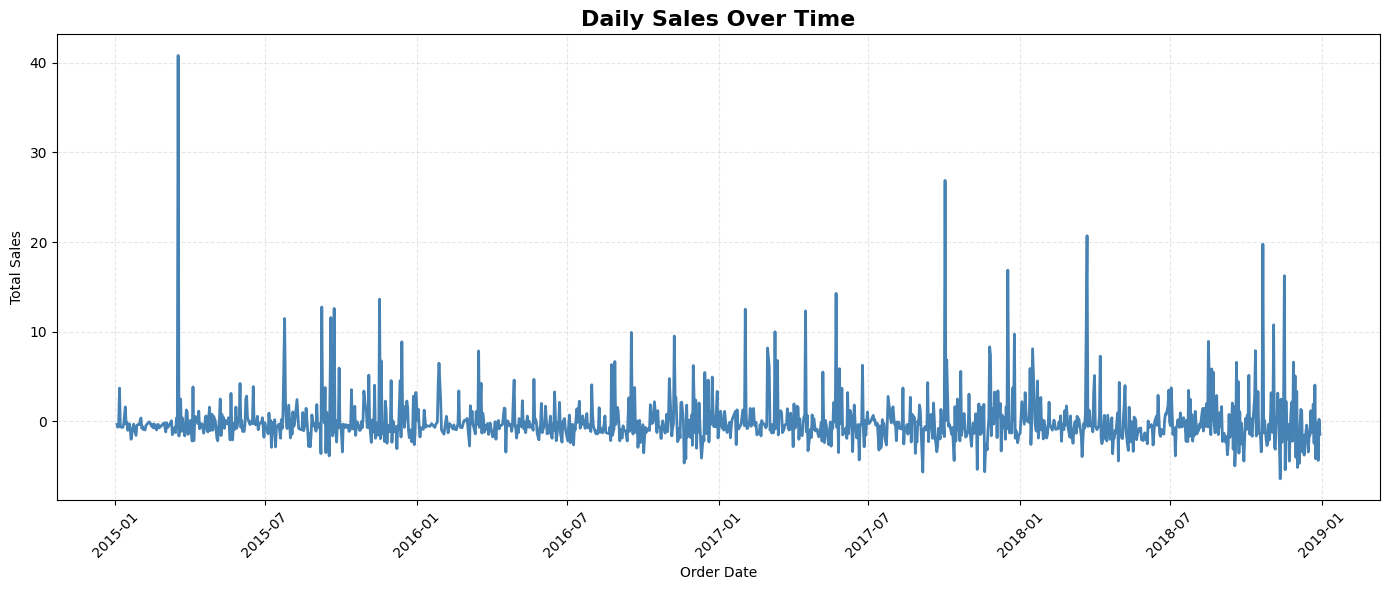

In [73]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

sales_date = (
    data.groupby('Order Date')['Sales']
        .sum()
        .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=sales_date,
    x='Order Date',
    y='Sales',
    color='steelblue',
    linewidth=2
)

plt.title('Daily Sales Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')

plt.grid(True, linestyle='--', alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Scatter plot using Matplotlib

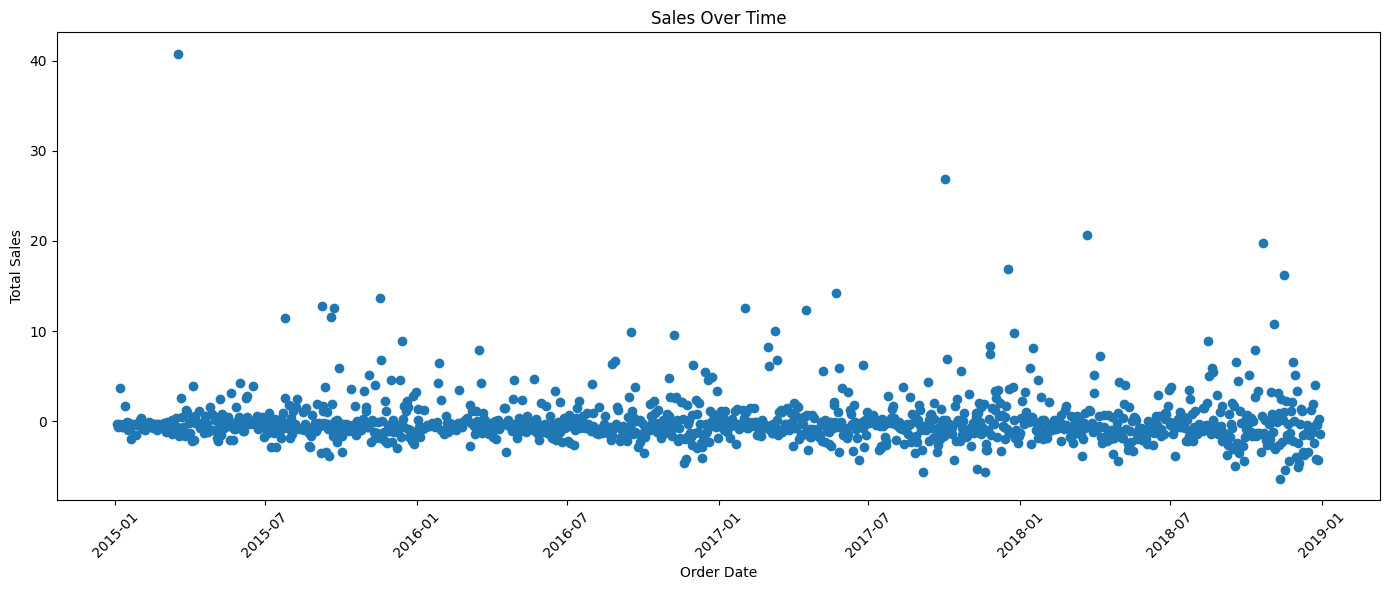

In [74]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

sales_date = (
    data.groupby('Order Date')['Sales']
        .sum()
        .reset_index()
)

plt.figure(figsize=(14,6))

plt.scatter(
    sales_date['Order Date'],
    sales_date['Sales']
)

plt.title('Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Histogram using Seaborn

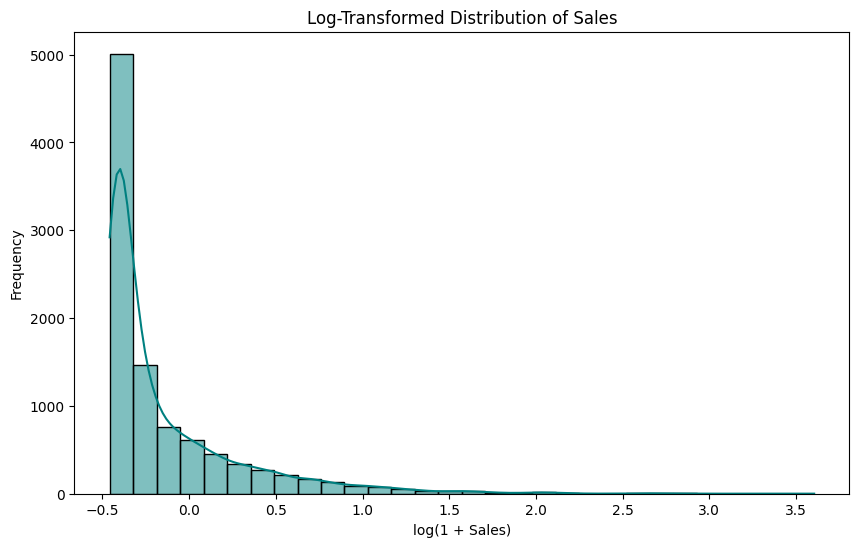

In [75]:
plt.figure(figsize=(10,6))
sns.histplot(
    np.log1p(data['Sales']),
    bins=30,
    kde=True,
    color='teal'
)

plt.title('Log-Transformed Distribution of Sales')
plt.xlabel('log(1 + Sales)')
plt.ylabel('Frequency')

plt.show()

# Create the bar chart

In [76]:
fig = px.bar(data, x=data['Order Date'].dt.year, y='Sales', 
             title='Bar Chart of Sales Over Time (Scaled)')

# Customize bars

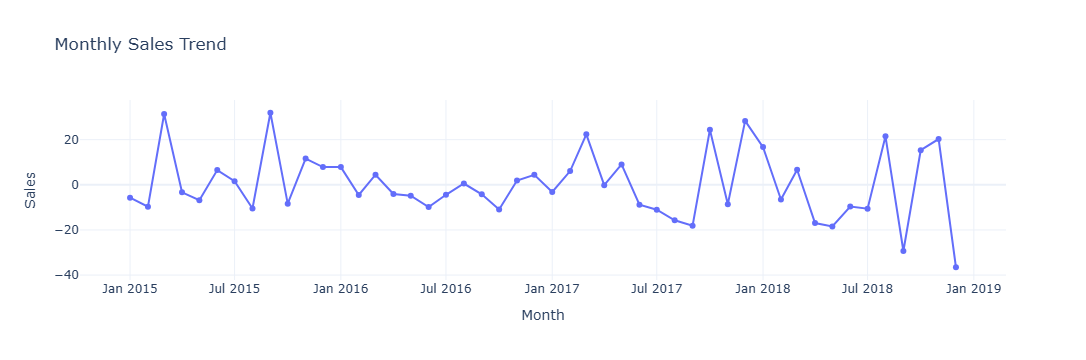

In [77]:
data['Month'] = data['Order Date'].dt.to_period('M').astype(str)

monthly_sales = (
    data.groupby('Month', as_index=False)['Sales']
        .sum()
)

fig = px.line(
    monthly_sales,
    x='Month',
    y='Sales',
    markers=True,
    title='Monthly Sales Trend'
)

fig.update_layout(template='plotly_white')

fig.show()

# Adjust y-axis range

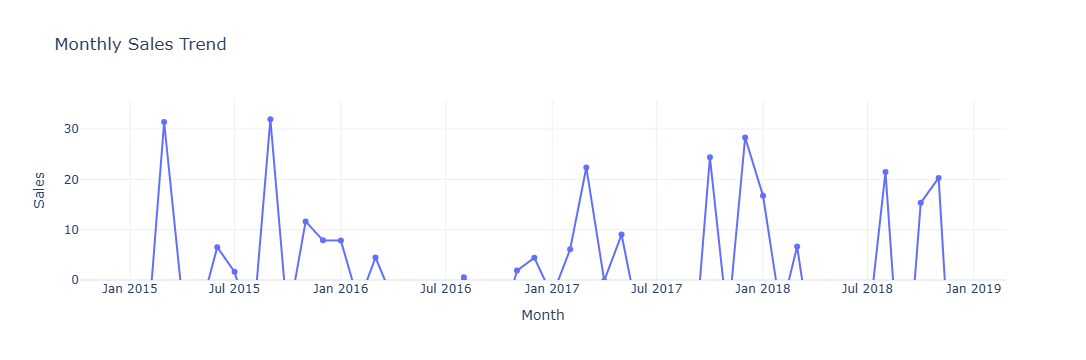

In [78]:
fig.update_layout(yaxis_range=[0, data['Sales'].max()])

# Heatmap using Seaborn

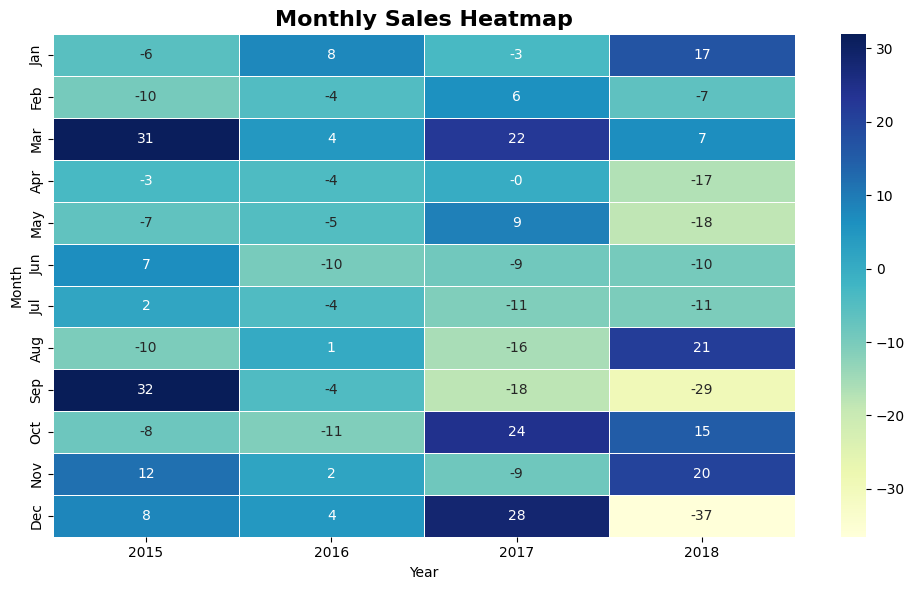

In [79]:
# Convert to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])

# Extract Year and Month
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.strftime('%b')

# Pivot table
heatmap_data = data.pivot_table(
    values='Sales',
    index='Month',
    columns='Year',
    aggfunc='sum'
)

# Order months correctly
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data = heatmap_data.reindex(month_order)

# Plot
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Monthly Sales Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Month')

plt.tight_layout()
plt.show()

# Area chart using Plotly

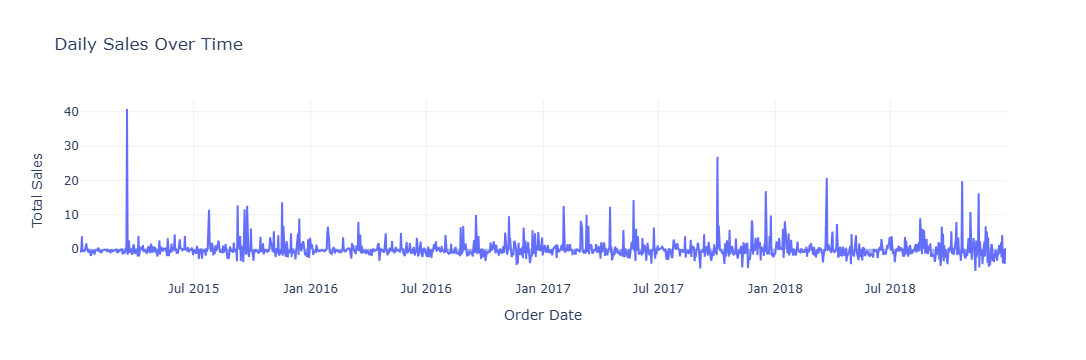

In [80]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

sales_date = (
    data.groupby('Order Date', as_index=False)['Sales']
        .sum()
)

fig = px.area(
    sales_date,
    x='Order Date',
    y='Sales',
    title='Daily Sales Over Time'
)

fig.update_traces(
    line=dict(width=2),
    opacity=0.7
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Order Date',
    yaxis_title='Total Sales',
    hovermode='x unified'
)

fig.show()

# Advanced Plot 1: Subplots using Matplotlib

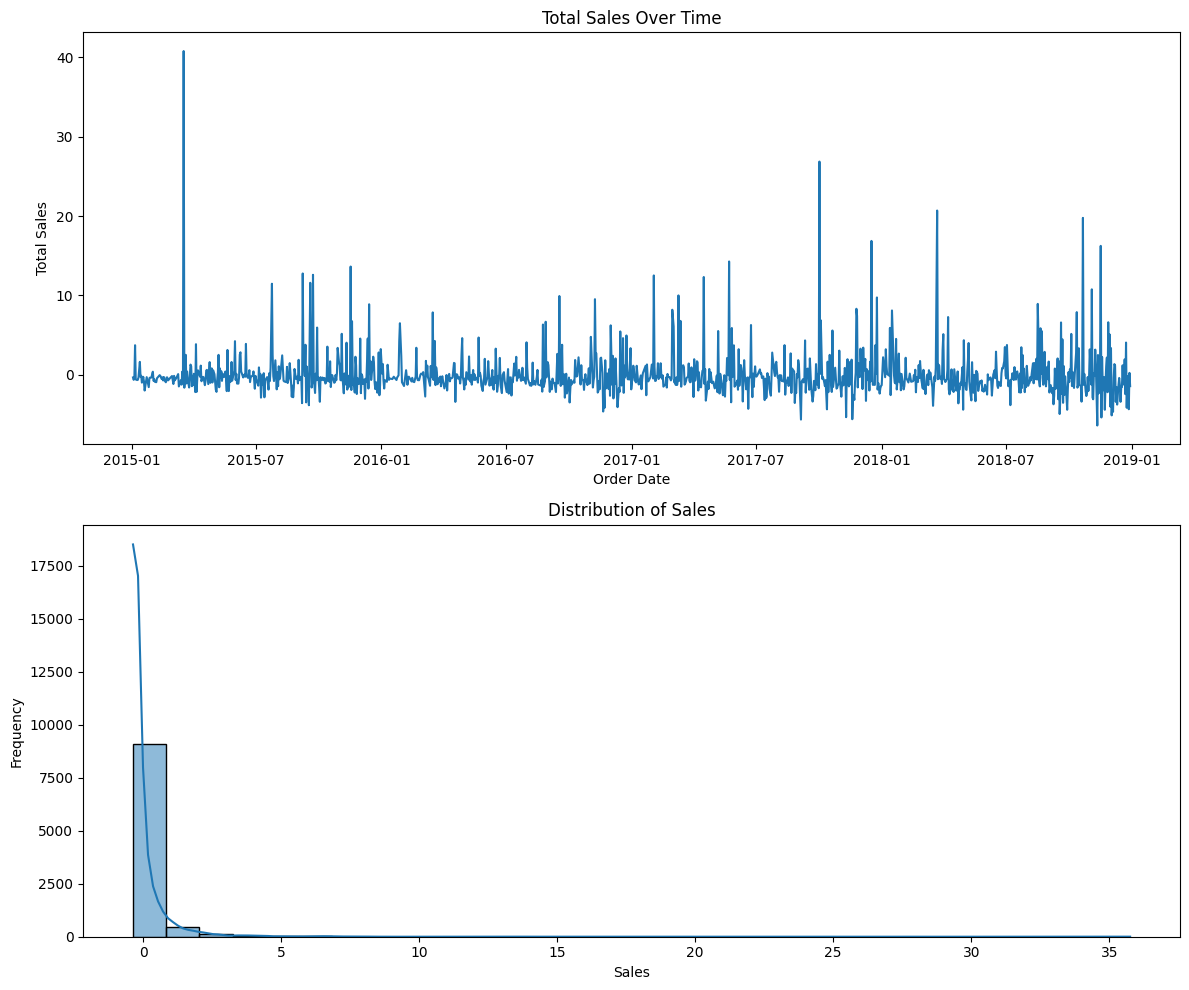

In [81]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

# Total sales by date
sales_date = data.groupby('Order Date', as_index=False)['Sales'].sum()

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Line plot
sns.lineplot(
    data=sales_date,
    x='Order Date',
    y='Sales',
    ax=axes[0]
)
axes[0].set_title('Total Sales Over Time')
axes[0].set_xlabel('Order Date')
axes[0].set_ylabel('Total Sales')

# Histogram
sns.histplot(
    data=data,
    x='Sales',
    bins=30,
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Distribution of Sales')
axes[1].set_xlabel('Sales')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Advanced Plot 2: Trend Analysis using Plotly

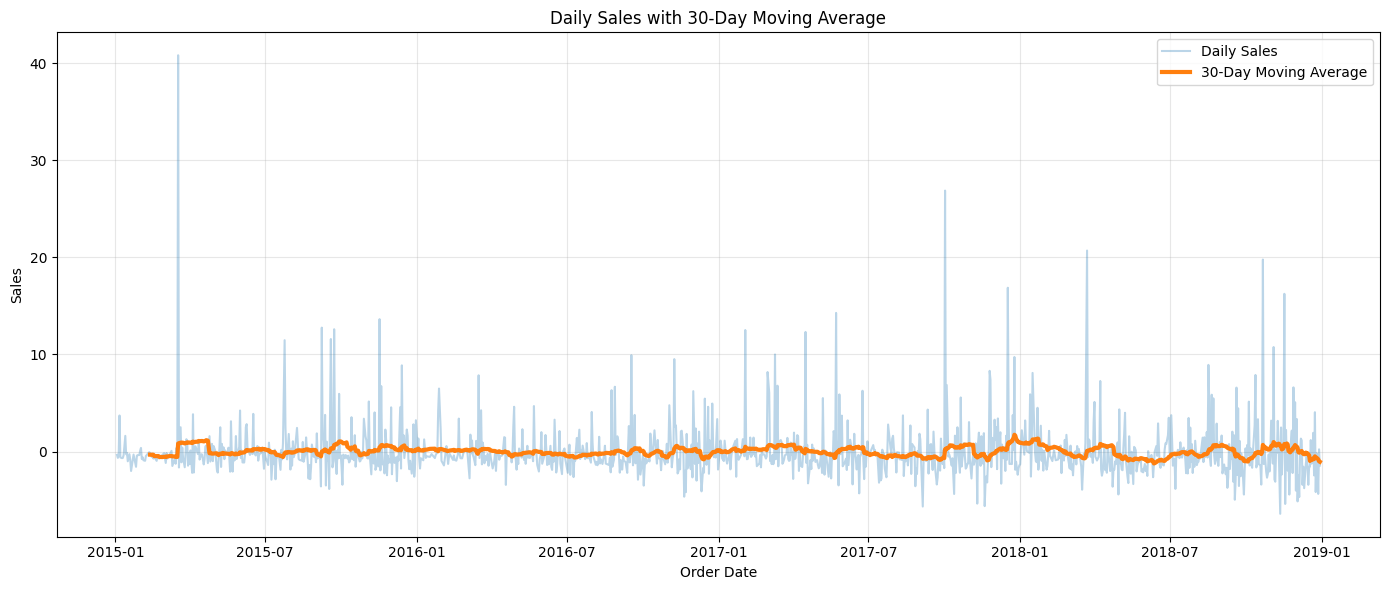

In [82]:
sales_date['Moving Average'] = (
    sales_date['Sales']
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    sales_date['Order Date'],
    sales_date['Sales'],
    alpha=0.3,
    label='Daily Sales'
)

plt.plot(
    sales_date['Order Date'],
    sales_date['Moving Average'],
    linewidth=3,
    label='30-Day Moving Average'
)

plt.title('Daily Sales with 30-Day Moving Average')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()